In [2]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

In [12]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [4]:
cat0 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_lrg_south_1.0.0_basic.fits'))
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_lrg_south_1.0.0_photom.fits'))
pz = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_lrg_south_1.0.0_pz.fits'))
cat = hstack([cat0, cat, pz], join_type='exact')
print(len(cat))

9144035


In [5]:
maskbits = [1, 8, 9, 11, 12, 13]

mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))
cat = cat[mask_clean]
print(len(cat))

0.10098823987440993
8220595


In [6]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gmag = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
    rmag = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
    zmag = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
    w1mag = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    w2mag = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
    zfibermag = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']/cat['MW_TRANSMISSION_Z'])

    gmag[~np.isfinite(gmag)] = 100.
    rmag[~np.isfinite(rmag)] = 100.
    zmag[~np.isfinite(zmag)] = 100.
    w1mag[~np.isfinite(w1mag)] = 100.
    w2mag[~np.isfinite(w2mag)] = 100.
    zfibermag[~np.isfinite(zfibermag)] = 100.

In [7]:
cat.add_columns([gmag, rmag, zmag, w1mag, w2mag, zfibermag], names=['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'zfibermag'])

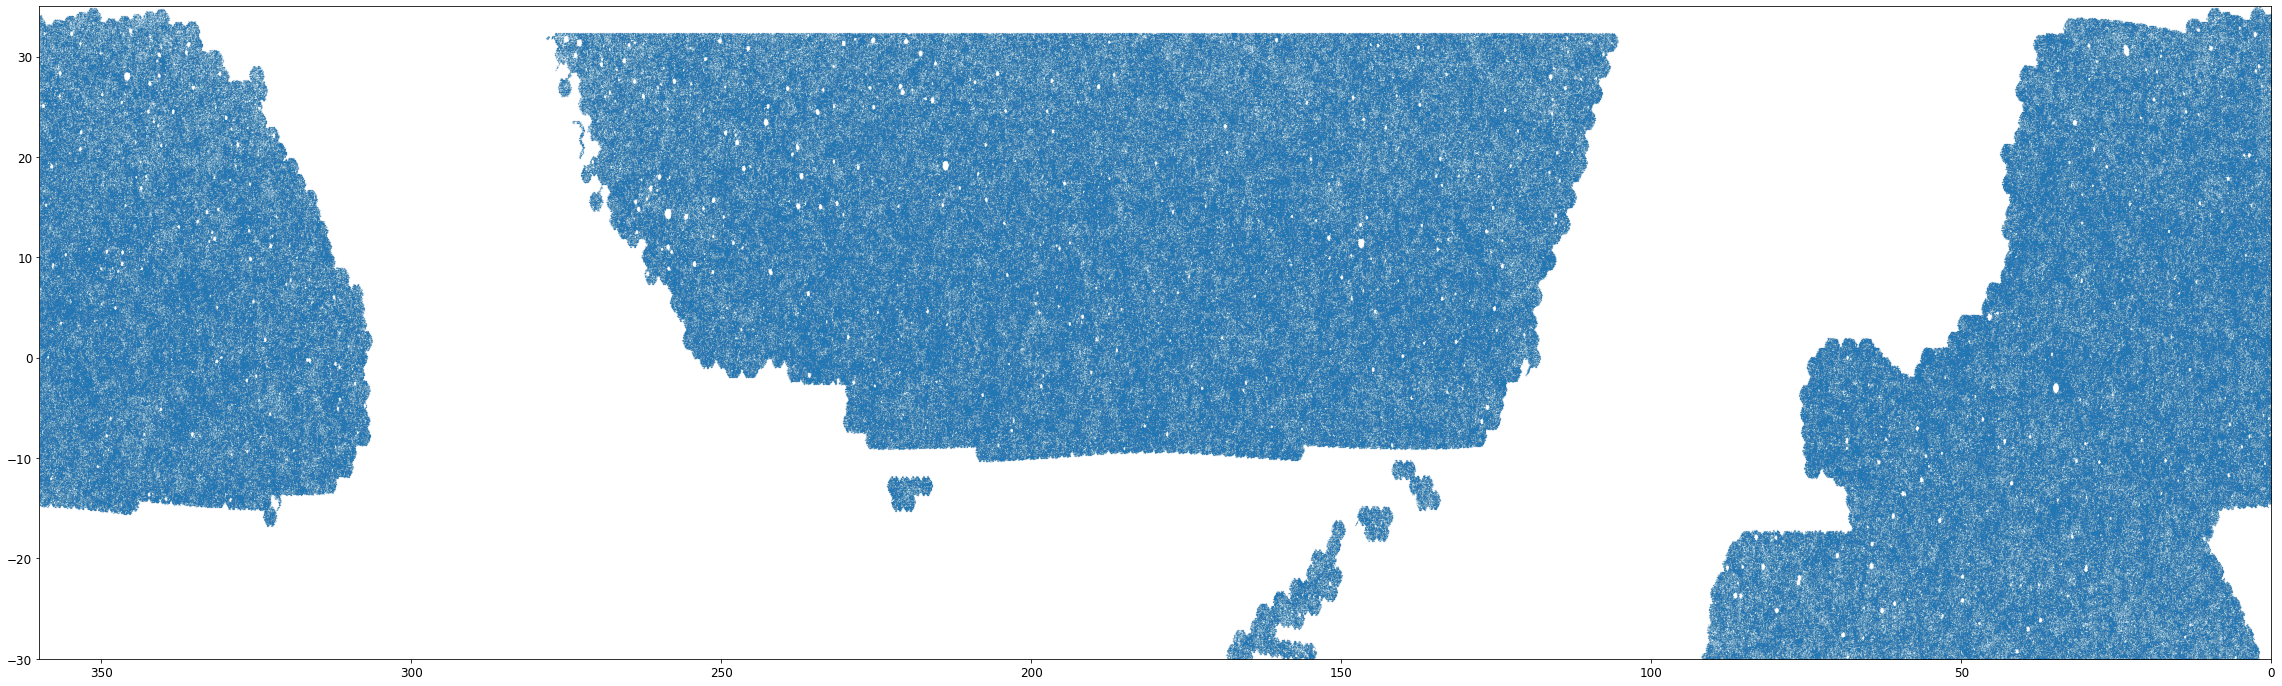

In [8]:
plt.figure(figsize=(40, 12))
plt.plot(cat['RA'], cat['DEC'], '.', ms=0.2, alpha=0.5)
plt.axis([360, 0, -30, 35])
plt.show()

---------
# r-W1 bins

3.3000011


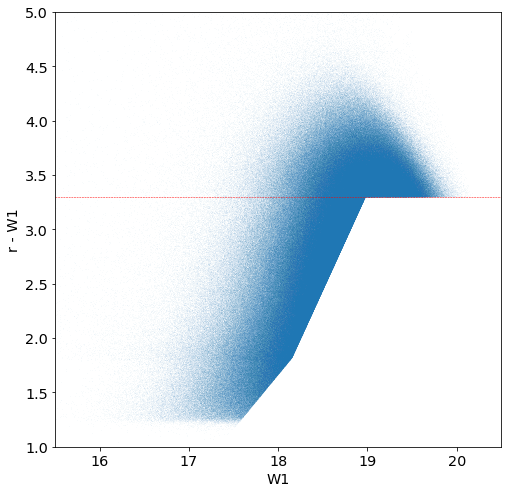

In [14]:
mask = w1mag>19
print((rmag - w1mag)[mask].min())

np.random.seed(613)
idx = np.random.choice(len(cat), size=int(2e6), replace=False)

plt.figure(figsize=(8, 8))
plt.plot(w1mag[idx], (rmag - w1mag)[idx], '.', ms=0.1, alpha=0.2)
plt.xlabel('W1')
plt.ylabel('r - W1')
plt.axhline(3.3, lw=0.5, color='r', ls='--')
plt.axis([15.5, 20.5, 1, 5.])
plt.show()

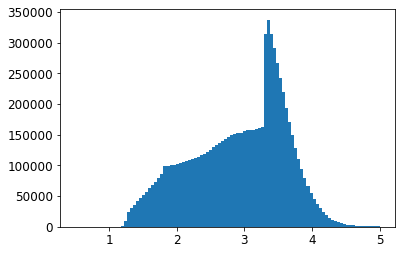

In [29]:
plt.hist(rmag - w1mag, 100, range=(0.5, 5))
plt.show()

In [30]:
np.percentile(rmag - w1mag, [0.001, 20, 40, 60, 80, 99.9])

array([1.13329103, 2.22999382, 2.80942726, 3.28309059, 3.53228378,
       4.81145971])

In [86]:
rw1_cuts = [2.24, 2.82, 3.3, 3.54]

for index in range(-1, len(rw1_cuts)):
    if index==-1:
        rw1_min, rw1_max = -np.inf, rw1_cuts[0]
    elif index==len(rw1_cuts)-1:
        rw1_min, rw1_max = rw1_cuts[index], np.inf
    else:
        rw1_min, rw1_max = rw1_cuts[index], rw1_cuts[index+1]
    mask = (cat['rmag']-cat['w1mag']>rw1_min) & (cat['rmag']-cat['w1mag']<rw1_max)
    print('{:.2f}% ({:.1f} per sqdeg)'.format(100*np.sum(mask)/len(mask), np.sum(mask)/len(mask)*600))

20.30% (121.8 per sqdeg)
20.13% (120.8 per sqdeg)
20.31% (121.9 per sqdeg)
19.77% (118.6 per sqdeg)
19.49% (116.9 per sqdeg)


---------
# Photo-z bins

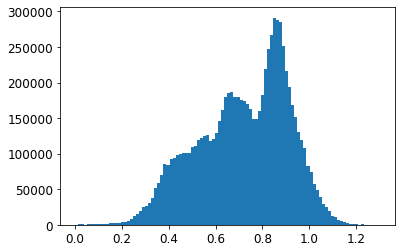

In [66]:
plt.hist(cat['Z_PHOT_MEDIAN'], 100, range=(0., 1.3))
plt.show()

In [67]:
print(cat['Z_PHOT_MEDIAN'].min(), cat['Z_PHOT_MEDIAN'].max())

-99.0 1.4738063


In [68]:
print(np.sum(cat['Z_PHOT_MEDIAN']<0))
print(np.sum(cat['Z_PHOT_MEDIAN']<0)/len(cat))

112
1.362431794778845e-05


In [69]:
mask = cat['Z_PHOT_MEDIAN']>=0
cat['Z_PHOT_MEDIAN'][mask].min()

0.006767422

In [70]:
np.percentile(cat['Z_PHOT_MEDIAN'], [0.001, 20, 40, 60, 80, 99.9])

array([-99.        ,   0.53962541,   0.68354958,   0.81022358,
         0.88985658,   1.15447474])

In [72]:
pz_cuts = [0.540, 0.683, 0.810, 0.890]

for index in range(-1, len(pz_cuts)):
    if index==-1:
        pz_min, pz_max = 0, pz_cuts[0]
    elif index==len(pz_cuts)-1:
        pz_min, pz_max = pz_cuts[index], np.inf
    else:
        pz_min, pz_max = pz_cuts[index], pz_cuts[index+1]
    mask = (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    print('{:.2f}% ({:.1f} per sqdeg)'.format(100*np.sum(mask)/len(mask), np.sum(mask)/len(mask)*600))

20.05% (120.3 per sqdeg)
19.86% (119.2 per sqdeg)
20.04% (120.3 per sqdeg)
20.08% (120.5 per sqdeg)
19.97% (119.8 per sqdeg)
